## Environment Setup

In [1]:
# 1.1 Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy.stats as stats

# Date/Time handling
from datetime import datetime, timedelta



In [2]:
df=pd.read_csv("SparePartsInventory!.csv")


In [3]:
part_summary=pd.read_csv("part_summary.csv")

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
df

,part_id,part_type,location_id,region,d,daily_demand_units,date,year_week,day_name,day_num,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,is_event,is_weekend,snap_flag,week_of_month,season,day_of_year,is_payday,is_working_Day,event_in_3days,event_in_7days,is_month_start,is_month_end,unit_cost,revenue,part_class,id,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,volatility_ratio_30,volatility_class,log_demand,ADI,CV_squared,intermittency_pct,demand_type,replenishment_strategy,volume_class,ABC_Class,XYZ_Class,ABC_XYZ,ABC_numeric,XYZ_numeric,volatility_numeric
0,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_1,1,2011-01-29,2011_W04,Saturday,1,1,2011,No Event,No Event,0,0,0,0,1,0,5,Early-Year Stock Reset,29,0,0,0,0,0,0,2.88,2.88,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110129_Dd_1,1.000000,NaN,1.000000,NaN,NaN,Unknown,0.693147,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,NaN
1,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_2,0,2011-01-30,2011_W04,Sunday,2,1,2011,No Event,No Event,0,0,0,0,1,0,5,Early-Year Stock Reset,30,1,0,0,1,0,0,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110130_Dd_2,0.500000,0.707107,0.500000,0.707107,1.414211,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0
2,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_3,0,2011-01-31,2011_W05,Monday,3,1,2011,No Event,No Event,0,0,0,0,0,0,5,Early-Year Stock Reset,31,1,1,0,0,0,1,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110131_Dd_3,0.333333,0.577350,0.333333,0.577350,1.732046,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0
3,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_4,2,2011-02-01,2011_W05,Tuesday,4,2,2011,No Event,No Event,1,1,0,0,0,1,1,Spring Promotions,32,1,1,0,0,1,0,2.88,5.76,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110201_Dd_4,0.750000,0.957427,0.750000,0.957427,1.276568,Stable,1.098612,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,2.0
4,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_5,0,2011-02-02,2011_W05,Wednesday,5,2,2011,No Event,No Event,1,0,1,0,0,1,1,Spring Promotions,33,0,1,0,0,0,0,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110202_Dd_5,0.600000,0.894427,0.600000,0.894427,1.490710,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735470,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1909,0,2016-04-20,2016_W16,Wednesday,5,4,2016,No Event,No Event,0,0,0,0,0,0,3,NaN,111,0,1,0,0,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160420_Dd_1909,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0
735471,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1910,0,2016-04-21,2016_W16,Thursday,6,4,2016,No Event,No Event,0,0,0,0,0,0,3,NaN,112,0,1,0,0,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160421_Dd_1910,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0
735472,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1911,0,2016-04-22,2016_W16,Friday,7,4,2016,No Event,No Event,0,0,0,0,0,0,4,NaN,113,0,1,0,0,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160422_Dd_1911,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0
735473,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1912,0,2016-04-23,2016_W16,Saturday,1,4,2016,No Event,No Event,0,0,0,0,1,0,4,NaN,114,0,0,0,1,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160423_Dd_1912,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0


## SKU Demand Classification using ADI vs CV² Framework



This scatterplot visualizes the classification of Stock Keeping Units (SKUs) based on two key statistical indicators of demand variability:

- **ADI (Average Demand Interval):** Measures the average number of time periods between non-zero demand occurrences.
- **CV² (Squared Coefficient of Variation):** Measures the variability of demand relative to its mean, squared to emphasize erratic behavior.

SKUs are grouped into four distinct demand types using the following threshold values:
- **ADI = 1.32** (vertical threshold)
- **CV² = 0.49** (horizontal threshold)

The classification zones are:

| Demand Type    | Characteristics                                      |
|----------------|------------------------------------------------------|
| **Smooth**      | Low ADI and low CV² — consistent and regular demand |
| **Intermittent**| High ADI and low CV² — infrequent but steady demand |
| **Erratic**     | Low ADI and high CV² — frequent but highly variable |
| **Lumpy**       | High ADI and high CV² — both infrequent and erratic demand |

Each point in the scatterplot represents an individual SKU. 
Color coding and annotations assist in quickly identifying the demand behavior, 
supporting appropriate forecasting model selection and inventory control strategies.


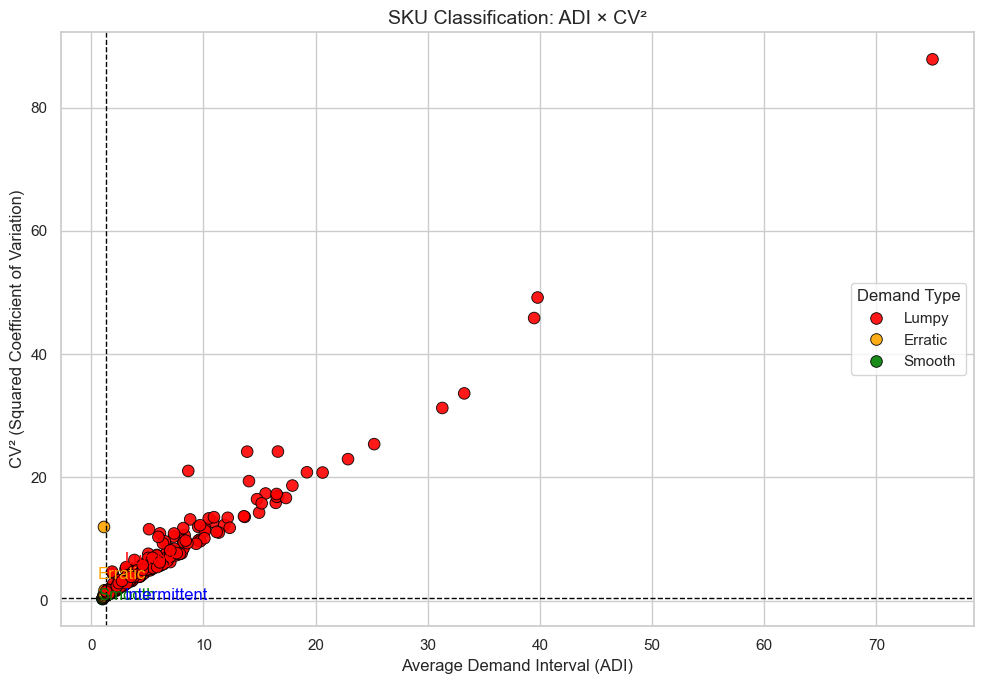

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")

# Scatterplot
sns.scatterplot(
    data=part_summary,
    x="ADI",
    y="CV_squared",
    hue="demand_type",
    palette={
        "Smooth": "green",
        "Intermittent": "blue",
        "Erratic": "orange",
        "Lumpy": "red"
    },
    alpha=0.9,
    s=70,
    edgecolor='black'
)

# Threshold lines
plt.axhline(y=0.49, color='black', linestyle='--', linewidth=1)
plt.axvline(x=1.32, color='black', linestyle='--', linewidth=1)

# Zone annotations
plt.text(0.6, 0.1, "Smooth", fontsize=12, color='green')
plt.text(0.6, 3.5, "Erratic", fontsize=12, color='orange')
plt.text(3, 0.1, "Intermittent", fontsize=12, color='blue')
plt.text(3, 6, "Lumpy", fontsize=12, color='red')

# Labels
plt.title("SKU Classification: ADI × CV²", fontsize=14)
plt.xlabel("Average Demand Interval (ADI)", fontsize=12)
plt.ylabel("CV² (Squared Coefficient of Variation)", fontsize=12)
plt.legend(title="Demand Type")
plt.tight_layout()
plt.show()

## FORECAST Methods Definition 

### Croston's Method for Intermittent Demand Forecasting

Croston's method is designed to forecast **intermittent demand**—where many periods have zero demand and non-zero values occur sporadically. It separates the demand process into:

1. **Demand size (z)** — the magnitude of demand when it occurs.
2. **Inter-demand interval (p)** — the number of periods between non-zero demands.

It then applies **exponential smoothing** separately to each and forecasts the demand as:

$$
\text{Forecast}_t = \frac{z_t}{p_t}
$$

This method avoids underestimation typical in simple exponential smoothing for sparse data.



In [7]:
import numpy as np
import pandas as pd

def croston_forecast(demand, alpha=0.1):
    demand = np.array(demand)
    n = len(demand)
    z = 0  # demand size
    p = 0  # interval
    q = 1  # counter
    first = True

    forecast = np.zeros(n)

    for t in range(n):
        if demand[t] > 0:
            if first:
                z = demand[t]
                p = q
                first = False
            else:
                z = alpha * demand[t] + (1 - alpha) * z
                p = alpha * q + (1 - alpha) * p
            q = 1
        else:
            q += 1

        forecast[t] = z / p if p > 0 else 0

    return forecast


In [8]:
def sba_forecast(demand, alpha=0.1):
    croston_series = croston_forecast(demand, alpha)
    return 0.95 * croston_series


###  TSB Method for Intermittent Demand Forecasting

The **Teunter–Syntetos–Babai (TSB)** method is an advanced intermittent demand forecasting model that improves upon Croston’s method by modeling the **probability of demand occurrence** directly, rather than using inter-demand intervals.

It smooths two components:
- **$z_t$**: Demand size when demand occurs
- **$p_t$**: Probability that demand occurs at time $t$

The TSB forecast at time $t$ is given by:

$$
\text{Forecast}_t = z_t \cdot p_t
$$

Where:
- $z_t$ is updated using exponential smoothing with smoothing constant $\alpha$
- $p_t$ is updated using exponential smoothing with smoothing constant $\beta$

---



In [9]:
def tsb_forecast(demand, alpha=0.1, beta=0.1):
    demand = np.array(demand)
    n = len(demand)
    z = 0  # demand size
    p = 0  # probability of demand
    first = True

    forecast = np.zeros(n)

    for t in range(n):
        if demand[t] > 0:
            if first:
                z = demand[t]
                p = 1
                first = False
            else:
                z = alpha * demand[t] + (1 - alpha) * z
                p = beta + (1 - beta) * p
        else:
            p = (1 - beta) * p

        forecast[t] = z * p

    return forecast


###  Prophet Forecasting for Daily SKU Demand

[**Facebook Prophet**](https://facebook.github.io/prophet/) is a time series forecasting library that automatically detects trend and seasonality components, making it well-suited for **daily SKU-level demand forecasting** with business seasonality patterns.

This implementation uses:
- **Daily and weekly seasonality** (enabled)
- **Yearly seasonality** (enabled)
- **No future extension** — forecast is aligned to historical data size only

####  Forecasting Logic
If the input time series has fewer than 30 valid (non-null) points, a **simple mean forecast** is returned. Otherwise, Prophet is trained on the data and fitted with:

 $$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$

Where:
- $g(t)$ is the piecewise linear/log trend
- $s(t)$ is the seasonal component (weekly/yearly)
- $h(t)$ is the holiday effect (disabled here)
- $\epsilon_t$ is the error term





#### Supresses the `cmdstanpy` INFO-level logs 

In [10]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)


In [11]:
from prophet import Prophet
import pandas as pd

def prophet_forecast(df_sku):
    # Prepare data for Prophet
    df_prophet = df_sku[['date', 'daily_demand_units']].rename(columns={
        'date': 'ds',
        'daily_demand_units': 'y'
    })
    
    # Drop missing values
    df_prophet = df_prophet.dropna()

    if len(df_prophet) < 30:
        return [df_prophet['y'].mean()] * len(df_prophet)

    # Fit Prophet model
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=0, freq='D')  # match historical size only
    forecast = model.predict(future)
    
    return forecast['yhat'].values



###  ETS Forecasting with Holt-Winters Exponential Smoothing

**ETS (Error-Trend-Seasonality)** models, particularly the **Holt-Winters** method, are used for time series forecasting where data exhibits **trend** and **seasonality**. This implementation uses the **additive** form for both trend and seasonality, making it ideal for data with **constant seasonal effects**.

---

####  Model Components
The model assumes:

$$
y_t = l_t + b_t + s_t + \epsilon_t
$$

Where:
- $l_t$ is the level component
- $b_t$ is the trend
- $s_t$ is the seasonal effect (with period `seasonal_periods`)
----

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def ets_forecast(demand, seasonal_periods=7):
    try:
        model = ExponentialSmoothing(demand, trend='add', seasonal='add', seasonal_periods=seasonal_periods)
        model_fit = model.fit(optimized=True)
        return model_fit.fittedvalues.tolist()
    except:
        return [np.mean(demand)] * len(demand)

### SARIMAX Forecasting for Daily SKU Demand

The **SARIMAX** model (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) is a powerful statistical forecasting tool that can handle:
- **Autoregression** (AR)
- **Differencing** (I)
- **Moving Average** (MA)
- **Seasonality** (SARIMA)
- **Exogenous variables** (not used here)

This implementation applies SARIMAX with **weekly seasonality (period=7)** for daily demand data.

---

####  Model Structure

$$
y_t = \phi_1 y_{t-1} + \theta_1 \varepsilon_{t-1} + \varepsilon_t + \text{Seasonal Terms}
$$
Configured SARIMAX parameters:
- `order=(1, 1, 1)` → ARIMA(1,1,1)
- `seasonal_order=(1, 0, 1, 7)` → seasonal ARMA with weekly pattern
- `disp=False` to suppress verbose output

---

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_forecast(df_sku):
    # Ensure the data is sorted by time
    df_sku = df_sku.sort_values("date")

    # Set the index to date
    df_sku.set_index("date", inplace=True)

    # If too few observations or all zero/same, fallback to mean
    if len(df_sku) < 20 or df_sku["daily_demand_units"].nunique() < 2:
        return [df_sku["daily_demand_units"].mean()] * len(df_sku)

    # Fit SARIMAX model (simple seasonal version with daily frequency)
    try:
        model = SARIMAX(
            df_sku["daily_demand_units"],
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 7),  # weekly seasonality
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        forecast = results.predict(start=0, end=len(df_sku)-1)
        return forecast.tolist()
    
    except Exception as e:
        print(f"Fallback for SKU due to SARIMAX failure: {e}")
        return [df_sku["daily_demand_units"].mean()] * len(df_sku)



###  Combination Forecast: Averaging Multiple Models

This function combines multiple forecast outputs using **simple averaging**. It is commonly used in **forecast ensembling** to reduce individual model biases and increase stability.

---

#### Methodology

Given multiple forecast vectors (from Prophet, Croston, SARIMAX), the function calculates:
$$
\text{Combined}_t = \frac{1}{n} \sum_{i=1}^{n} \text{Forecast}_{i,t}
$$

Where:
- $n$ is the number of forecast methods
- $t$ is the time index

---

In [14]:
def combination_forecast(*forecast_lists):
    combined = np.mean(np.array(forecast_lists), axis=0)
    return combined.tolist()

##  Best-Fit Probability Distribution Finder using Kolmogorov-Smirnov Test



This function identifies the **best-fitting statistical distribution** for a given demand series using the **Kolmogorov–Smirnov (K-S) goodness-of-fit test**.

---

#### Objective

To find the statistical distribution (e.g., Poisson, Normal, Exponential) that most closely matches the input `demand_series` data.

The function evaluates each candidate distribution by computing the **K-S statistic**:

$$
D = \sup_x |F_n(x) - F(x)|
$$

Where:
- \( F_n(x) \) is the empirical distribution function of the data
- \( F(x) \) is the CDF of the tested theoretical distribution
- The distribution with the **lowest \( D \)** value is selected as the best fit.

---


In [15]:
import scipy.stats as stats

def fit_best_distribution(demand_series):
    distributions = {
        "Poisson": stats.poisson,
        "Exponential": stats.expon,
        "Gamma": stats.gamma,
        "Log-Normal": stats.lognorm,
        "Normal": stats.norm,
        "Negative Binomial": stats.nbinom
    }

    best_fit = None
    best_ks_stat = float('inf')

    for dist_name, dist in distributions.items():
        try:
            params = dist.fit(demand_series)
            D, _ = stats.kstest(demand_series, dist_name.lower(), args=params)
            if D < best_ks_stat:
                best_ks_stat = D
                best_fit = dist_name
        except Exception:
            continue

    return best_fit


##  Mapping Best-Fit Distributions to SKUs



This step identifies and assigns the **statistically best-fitting probability distribution** for the non-zero demand history of each `part_id` (SKU). It uses the `fit_best_distribution` function—based on the Kolmogorov–Smirnov (K-S) goodness-of-fit test—to compare multiple candidate distributions such as Poisson, Normal, Gamma, and Log-Normal.

Only **non-zero daily demand values** are considered to avoid distortion from intermittent or lumpy demand patterns.



In [16]:
distribution_map = (
    df.groupby("part_id")["daily_demand_units"]
    .apply(lambda x: fit_best_distribution(x[x > 0]))  
)

part_summary = part_summary.merge(distribution_map, on="part_id", how="left")


## Forecast Model Assignment

###  Forecast Model Assignment Logic Based on SKU Attributes

This function selects the most appropriate **forecasting model** for each SKU based on its demand type, ABC importance class, XYZ volatility class, and overall demand volatility. The strategy is rule-based and prioritizes interpretability and alignment with time series behavior patterns.

---

####  Assignment Logic

| Condition                                                                 | Selected Model |
|---------------------------------------------------------------------------|----------------|
| Highly volatile and important SKUs (`A` or `B` class)                     | `Prophet`      |
| Lumpy and highly unpredictable (Z class)                                  | `TSB`          |
| Intermittent with moderate regularity (Y class)                           | `Croston`      |
| Erratic and high-value (A class)                                          | `SARIMAX`      |
| Smooth and seasonal                                                       | `ETS`          |
| Default / fallback (if none of the above applies)                         | `Combination`  |

---

In [17]:
def assign_forecast_model(row):
    demand_type = row['demand_type']
    abc = row['ABC_Class']
    xyz = row['XYZ_Class']
    volatility = row['volatility_class']

    # 1. High-volatility + high-importance SKUs → Prophet (probabilistic, interpretable)
    if volatility == "Highly Volatile" and abc in ["A", "B"]:
        return "Prophet"

    # 2. Lumpy and highly unpredictable SKUs → TSB (best for zero-heavy series)
    if demand_type == "Lumpy" and xyz == "Z":
        return "TSB"

    # 3. Intermittent but moderately regular → Croston (event spacing driven)
    if demand_type == "Intermittent" and xyz == "Y":
        return "Croston"

    # 4. Erratic + high-value SKUs (event-driven & promotion-sensitive) → SARIMAX
    if demand_type == "Erratic" and abc == "A":
        return "SARIMAX"

    # 5. Smooth & seasonal → ETS (classic trend + seasonality)
    if demand_type == "Smooth":
        return "ETS"

    # 6. Fallback: Combine multiple methods (TSB + Croston + Prophet)
    return "Combination"


In [18]:
part_summary['assigned_model'] = part_summary.apply(assign_forecast_model, axis=1)

In [19]:
part_summary['assigned_model'].value_counts()

assigned_model
TSB            364
Prophet         43
SARIMAX         31
Combination     15
ETS              9
Name: count, dtype: int64

## Forecast Model SKU Segmentation

In [20]:
# Step 1: Create lookup dictionaries per model
skus_tsb = part_summary[part_summary['assigned_model'] == 'TSB']['part_id'].unique()
skus_croston = part_summary[part_summary['assigned_model'] == 'Croston']['part_id'].unique()
skus_prophet = part_summary[part_summary['assigned_model'] == 'Prophet']['part_id'].unique()
skus_sarimax = part_summary[part_summary['assigned_model'] == 'SARIMAX']['part_id'].unique()
skus_ets = part_summary[part_summary['assigned_model'] == 'ETS']['part_id'].unique()
skus_combination = part_summary[part_summary['assigned_model'] == 'Combination']['part_id'].unique()


In [21]:
# Step 2: Subset the main dataframe for each group
df_tsb = df[df['part_id'].isin(skus_tsb)]
df_croston = df[df['part_id'].isin(skus_croston)]
df_prophet = df[df['part_id'].isin(skus_prophet)]
df_sarimax = df[df['part_id'].isin(skus_sarimax)]
df_ets = df[df['part_id'].isin(skus_ets)]
df_combination = df[df['part_id'].isin(skus_combination)]


## TSB forecast

In [22]:
forecast_results = []

# TSB
for sku in df_tsb['part_id'].unique():
    sku_df = df_tsb[df_tsb['part_id'] == sku].sort_values("date")
    series = sku_df['daily_demand_units'].values
    forecast = tsb_forecast(series)
    forecast_results.extend(zip(
        [sku] * len(forecast),
        sku_df['date'],
        sku_df['id'],  # <-- include id
        forecast,
        ['TSB'] * len(forecast)
    ))


## Croston Forecast

In [23]:

# Croston
for sku in df_croston['part_id'].unique():
    sku_df = df_croston[df_croston['part_id'] == sku].sort_values("date")
    series = sku_df['daily_demand_units'].values
    forecast = croston_forecast(series)
    forecast_results.extend(zip(
        [sku] * len(forecast),
        sku_df['date'],
        sku_df['id'],
        forecast,
        ['Croston'] * len(forecast)
    ))


## Prophet Forecast

In [24]:

# Prophet
for sku in df_prophet['part_id'].unique():
    sku_df = df_prophet[df_prophet['part_id'] == sku].sort_values("date")
    forecast = prophet_forecast(sku_df)  
    forecast_results.extend(zip(
        [sku] * len(forecast),
        sku_df['date'],
        sku_df['id'],
        forecast,
        ['Prophet'] * len(forecast)
    ))



15:58:22 - cmdstanpy - INFO - Chain [1] start processing
15:58:23 - cmdstanpy - INFO - Chain [1] done processing
15:58:23 - cmdstanpy - INFO - Chain [1] start processing
15:58:24 - cmdstanpy - INFO - Chain [1] done processing
15:58:24 - cmdstanpy - INFO - Chain [1] start processing
15:58:24 - cmdstanpy - INFO - Chain [1] done processing
15:58:25 - cmdstanpy - INFO - Chain [1] start processing
15:58:25 - cmdstanpy - INFO - Chain [1] done processing
15:58:26 - cmdstanpy - INFO - Chain [1] start processing
15:58:26 - cmdstanpy - INFO - Chain [1] done processing
15:58:27 - cmdstanpy - INFO - Chain [1] start processing
15:58:27 - cmdstanpy - INFO - Chain [1] done processing
15:58:28 - cmdstanpy - INFO - Chain [1] start processing
15:58:28 - cmdstanpy - INFO - Chain [1] done processing
15:58:29 - cmdstanpy - INFO - Chain [1] start processing
15:58:29 - cmdstanpy - INFO - Chain [1] done processing
15:58:29 - cmdstanpy - INFO - Chain [1] start processing
15:58:29 - cmdstanpy - INFO - Chain [1]

## SARIMAX Forecast

In [25]:
# SARIMAX
for sku in df_sarimax['part_id'].unique():
    sku_df = df_sarimax[df_sarimax['part_id'] == sku].sort_values("date")
    forecast = sarimax_forecast(sku_df)
    forecast_results.extend(zip(
        [sku] * len(forecast),
        sku_df['date'],
        sku_df['id'],
        forecast,
        ['SARIMAX'] * len(forecast)
    ))



C:\Users\uppuk\miniconda3\envs\spareparts\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\uppuk\miniconda3\envs\spareparts\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\uppuk\miniconda3\envs\spareparts\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\uppuk\miniconda3\envs\spareparts\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\uppuk\m

## ETS Forecast

In [26]:
# ETS
for sku in df_ets['part_id'].unique():
    sku_df = df_ets[df_ets['part_id'] == sku].sort_values("date")
    series = sku_df['daily_demand_units'].values
    forecast = ets_forecast(series)
    forecast_results.extend(zip(
        [sku] * len(forecast),
        sku_df['date'],
        sku_df['id'],
        forecast,
        ['ETS'] * len(forecast)
    ))



## Combination Forecast

In [27]:
# Combination (TSB + Croston + Prophet)
for sku in df_combination['part_id'].unique():
    sku_df = df_combination[df_combination['part_id'] == sku].sort_values("date")
    series = sku_df['daily_demand_units'].values
    f1 = tsb_forecast(series)
    f2 = croston_forecast(series)
    f3 = prophet_forecast(sku_df)
    combined = combination_forecast(f1, f2, f3)
    forecast_results.extend(zip(
        [sku] * len(combined),
        sku_df['date'],
        sku_df['id'],
        combined,
        ['Combination'] * len(combined)
    ))

15:59:38 - cmdstanpy - INFO - Chain [1] start processing
15:59:38 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:40 - cmdstanpy - INFO - Chain [1] start processing
15:59:40 - cmdstanpy - INFO - Chain [1] done processing
15:59:41 - cmdstanpy - INFO - Chain [1] start processing
15:59:41 - cmdstanpy - INFO - Chain [1] done processing
15:59:41 - cmdstanpy - INFO - Chain [1] start processing
15:59:41 - cmdstanpy - INFO - Chain [1] done processing
15:59:42 - cmdstanpy - INFO - Chain [1] start processing
15:59:42 - cmdstanpy - INFO - Chain [1] done processing
15:59:43 - cmdstanpy - INFO - Chain [1] start processing
15:59:43 - cmdstanpy - INFO - Chain [1] done processing
15:59:43 - cmdstanpy - INFO - Chain [1] start processing
15:59:44 - cmdstanpy - INFO - Chain [1]

## Forecast Dataframe for further analysis.

In [28]:
forecast_df = pd.DataFrame(forecast_results, columns=["part_id", "date", "id", "forecast", "model_used"])


In [29]:
forecast_df['model_used'].value_counts()

model_used
TSB            559579
Prophet         70779
SARIMAX         65345
Combination     20554
ETS             17347
Name: count, dtype: int64

## Intermittent Demand Metrics

  
### This Function Calculates a comprehensive suite of the best-researched forecast accuracy metrics tailored for intermittent demand.

    This function removes less accurate metrics like MAPE and uses the standard
    definitions for MASE and other advanced metrics.

    Args:
        y_actual (np.ndarray): The array of actual observed values (the test set).
        y_forecast (np.ndarray): The array of forecasted values.
        y_train (np.ndarray): The array of historical training data, needed for standard MASE scaling.
        unit_cost (float): The cost of one unit of the SKU, for cost-based metrics.
        holding_cost_rate (float): The annual cost to hold one dollar of inventory (e.g., 0.25 for 25%).
        stockout_cost_multiplier (float): A multiplier for unit_cost to estimate the per-unit cost of a stockout.

    Returns:
        dict: A dictionary containing the most relevant and robust metrics.
    

In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_intermittent_demand_metrics(
    y_actual: np.ndarray,
    y_forecast: np.ndarray,
    unit_cost: float,
    holding_cost_rate: float = 0.25,
    stockout_cost_multiplier: float = 5.0
) -> dict:
  
    # --- 1. Initial Validation and Setup ---
    y_actual = np.asarray(y_actual)
    y_forecast = np.asarray(y_forecast)

    if y_actual.shape[0] == 0 or y_actual.shape != y_forecast.shape:
        return {}

    # --- 2. Tier 1: Essential Statistical Metrics ---
    mae = mean_absolute_error(y_actual, y_forecast)
    rmse = np.sqrt(mean_squared_error(y_actual, y_forecast))
    bias = np.mean(y_forecast - y_actual) # Measures consistent over/under forecasting

    # --- 3. Tier 2: Best-in-Class Scaled Metrics (MASE & RMSSE) ---
    
    if len(y_actual) < 2:
        mase, rmsse = np.nan, np.nan
    else:
        # Calculate naive errors on the test set (out-of-sample)
        out_of_sample_naive_errors = y_actual[1:] - y_actual[:-1]

        # MASE (Mean Absolute Scaled Error)
        mase_denominator = np.mean(np.abs(out_of_sample_naive_errors))
        mase = mae / mase_denominator if mase_denominator > 1e-9 else np.inf

        # RMSSE (Root Mean Squared Scaled Error)
        rmsse_denominator = np.mean(np.square(out_of_sample_naive_errors))
        rmsse = rmse / np.sqrt(rmsse_denominator) if rmsse_denominator > 1e-9 else np.inf

    # --- 4. Tier 3: Critical Business-Oriented Metric ---
    # This metric calculates the financial cost of the forecast errors.
    error = y_actual - y_forecast
    unit_holding_cost = unit_cost * holding_cost_rate
    unit_stockout_cost = unit_cost * stockout_cost_multiplier

    holding_costs = np.maximum(0, -error) * unit_holding_cost
    stockout_costs = np.maximum(0, error) * unit_stockout_cost

    avg_cost_impact_per_period = np.mean(holding_costs + stockout_costs)

    # --- 5. Return the final, curated metrics dictionary ---
    return {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "Bias": round(bias, 4),
        "MASE": round(mase, 4),
        "RMSSE": round(rmsse, 4),
        "Avg_Cost_Impact": round(avg_cost_impact_per_period, 2),
        "Actual_Mean": round(np.mean(y_actual), 4),
        "Forecast_Mean": round(np.mean(y_forecast), 4)
    }


In [31]:
# Create merged df with actuals
merged = df.merge(forecast_df[["id", "forecast", "model_used"]], on="id", how="left")
merged = merged.sort_values(by=["part_id", "date"])



In [32]:
merged['model_used'].value_counts()

model_used
TSB            559579
Prophet         70779
SARIMAX         65345
Combination     20554
ETS             17347
Name: count, dtype: int64

## Model Evaluation Across SKUs and Forecasting Methods



This step evaluates the forecasting performance for each SKU–method combination in the dataset. The `merged` DataFrame is grouped by `part_id` and the model used (`model_used`). For each group:

- A custom metric evaluation function (`calculate_intermittent_demand_metrics`) is applied.
- The function calculates accuracy and cost-sensitive metrics using actual demand, forecasts, and unit cost.
- Metadata such as demand type and ABC/XYZ classification are preserved for analysis.

The results are compiled into a structured `accuracy_df` table for further reporting, comparison, or visualization of model performance across segments.


In [33]:
# Evaluate per SKU and Method
results = []

for (sku, method), group in merged.groupby(["part_id", "model_used"]):
    metrics = calculate_intermittent_demand_metrics(group["daily_demand_units"], group["forecast"],group['unit_cost'])
    
    results.append({
        "part_id": sku,
        "method_used": method,
        "demand_type": group["demand_type"].iloc[0],
        "ABC_Class": group["ABC_Class"].iloc[0],
        "XYZ_Class": group["XYZ_Class"].iloc[0],
        **metrics
    })

accuracy_df = pd.DataFrame(results)


In [34]:
accuracy_df


,part_id,method_used,demand_type,ABC_Class,XYZ_Class,MAE,RMSE,Bias,MASE,RMSSE,Avg_Cost_Impact,Actual_Mean,Forecast_Mean
0,BRAKE_PAD_1_003,TSB,Lumpy,C,Z,0.2335,0.4024,0.0032,0.8806,0.6590,1.79,0.1521,0.1553
1,BRAKE_PAD_1_005,TSB,Lumpy,A,Z,0.7825,1.3869,0.0040,0.7180,0.6786,6.83,0.9181,0.9221
2,BRAKE_PAD_1_043,SARIMAX,Erratic,A,Y,4.8524,7.2158,0.1313,0.8697,0.8581,22.61,9.7943,9.9256
3,BRAKE_PAD_1_049,TSB,Lumpy,C,Z,0.4217,0.7569,0.0048,0.7983,0.6603,2.39,0.3638,0.3686
4,BRAKE_PAD_1_069,TSB,Lumpy,C,Z,0.3073,0.6213,0.0164,0.8681,0.6775,1.95,0.2079,0.2243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,LED_PANEL_2_124,TSB,Lumpy,C,Z,0.5619,1.2104,0.0094,0.8663,0.6944,0.33,0.4010,0.4104
458,LED_PANEL_2_125,TSB,Lumpy,C,Z,0.2183,0.4290,0.0037,0.8908,0.6853,0.55,0.1516,0.1553
459,LED_PANEL_2_130,Prophet,Lumpy,B,Z,0.3142,0.4813,0.0001,0.9931,0.7139,5.78,0.2007,0.2008
460,LED_PANEL_2_143,TSB,Lumpy,C,Z,0.2294,0.6497,0.0012,0.8762,0.6764,0.60,0.1399,0.1411


## Forecasting Accuracy Summary for Intermittent Demand

This analysis script provides a comprehensive summary of forecasting performance using industry-standard metrics. It focuses on both statistical accuracy and financial impact to guide model selection and SKU-level intervention strategies.

#### **1. Accuracy by Demand Type**
For each demand type (Smooth, Intermittent, Erratic, Lumpy), the script calculates the mean of key accuracy metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MASE** (Mean Absolute Scaled Error)
- **RMSSE** (Root Mean Squared Scaled Error)
- **Bias** (Directional tendency of forecasts)
- **Avg_Cost_Impact** (Financial loss or savings due to forecast error)

This helps identify which demand types are easier or harder to forecast accurately.

#### **2. Accuracy by Forecasting Method**
Aggregates accuracy and cost impact by model used (e.g., Croston, TSB, Prophet, SARIMAX). It reveals:
- The cost-effectiveness of each method across the dataset.
- Which models are better suited for large-scale deployment.

#### **3. Top 10 SKUs with Lowest Financial Impact**
Lists the SKUs with the most cost-efficient forecasts. These items are considered "well-forecasted" and may not need model adjustment or safety stock changes.

#### **4. Bottom 10 SKUs with Highest Financial Impact**
Highlights SKUs where poor forecasts result in significant financial penalties. These items should be prioritized for:
- Model tuning
- Safety stock recalibration
- Process investigation (e.g., promotions, anomalies)

This structured breakdown supports continuous improvement in demand planning and inventory optimization.


In [35]:
# --- Accuracy Summary Analysis ---
# This script evaluates forecasting performance using best-practice metrics for intermittent demand.

# 1. Accuracy by Demand Type
# Includes Bias, RMSSE, and Avg_Cost_Impact for financial relevance.
print("\nAccuracy by Demand Type:")
summary_by_type = accuracy_df.groupby("demand_type")[
    ["MAE", "RMSE", "MASE", "RMSSE", "Bias", "Avg_Cost_Impact"]
].mean().round(4)
print(summary_by_type.to_markdown())

# 2. Accuracy by Forecasting Method
# Highlights cost-effectiveness of each method on average.
print("\nAccuracy by Forecasting Method:")
summary_by_method = accuracy_df.groupby("method_used")[
    ["MAE", "RMSE", "MASE", "RMSSE", "Bias", "Avg_Cost_Impact"]
].mean().round(4)
print(summary_by_method.to_markdown())

# 3. Top 10 SKUs with Lowest Financial Impact
# Identifies SKUs with the most financially efficient forecasts.
print("\nTop 10 SKUs with Lowest Financial Impact:")
top_skus_by_cost = accuracy_df.sort_values("Avg_Cost_Impact", ascending=True).head(10)
print(top_skus_by_cost[
    ["part_id", "demand_type", "method_used", "Avg_Cost_Impact", "MASE", "Bias"]
].to_markdown(index=False))

# 4. Bottom 10 SKUs with Highest Financial Impact
# Helps identify SKUs with underperforming forecasts for correction.
print("\nBottom 10 SKUs with Highest Financial Impact:")
worst_skus_by_cost = accuracy_df.sort_values("Avg_Cost_Impact", ascending=False).head(10)
print(worst_skus_by_cost[
    ["part_id", "demand_type", "method_used", "Avg_Cost_Impact", "MASE", "Bias"]
].to_markdown(index=False))



Accuracy by Demand Type:
| demand_type   |    MAE |   RMSE |   MASE |   RMSSE |   Bias |   Avg_Cost_Impact |
|:--------------|-------:|-------:|-------:|--------:|-------:|------------------:|
| Erratic       | 2.6053 | 3.9542 | 0.7708 |  0.7353 | 0.0301 |           12.1997 |
| Lumpy         | 0.6546 | 0.9761 | 0.8306 |  0.6886 | 0.0075 |            6.6818 |
| Smooth        | 2.9633 | 3.892  | 0.7759 |  0.7622 | 0      |           16.9678 |

Accuracy by Forecasting Method:
| method_used   |    MAE |   RMSE |   MASE |   RMSSE |    Bias |   Avg_Cost_Impact |
|:--------------|-------:|-------:|-------:|--------:|--------:|------------------:|
| Combination   | 1.5079 | 1.9315 | 0.7724 |  0.7048 |  0.0337 |           10.7627 |
| ETS           | 2.9633 | 3.892  | 0.7759 |  0.7622 |  0      |           16.9678 |
| Prophet       | 0.3456 | 0.5366 | 0.9734 |  0.7145 | -0.0003 |            6.9747 |
| SARIMAX       | 2.6907 | 4.1235 | 0.7762 |  0.7404 |  0.0337 |           12.4487 |
| TSB      

In [36]:
from ipywidgets import interact, widgets

## Interactive Forecast Plot for Individual SKUs



This interactive visualization tool allows users to explore actual vs. forecasted demand for each SKU individually using an IPython widget and Plotly.

#### **Key Features**:
- **Dropdown Selector**: A widget allows users to select any `part_id` (SKU) from the dataset.
- **Forecast Visualization**: For the selected SKU, a time series plot is generated with:
  - **Blue Line**: Actual demand (`daily_demand_units`)
  - **Green Dashed Line**: Forecasted demand (`forecast`)
- **Contextual Title**: The plot title dynamically displays the SKU's ID, demand type (e.g., Smooth, Lumpy), and the forecasting model used (e.g., TSB, Prophet).
- **Unified Hovermode**: Enables precise reading of values across both traces.

#### **Usage**:
This plot is designed to help data analysts and supply chain professionals:
- Visually assess the quality of forecasting models per SKU.
- Detect patterns of underforecasting or overforecasting.
- Quickly identify anomalies or demand spikes not captured by the model.

Ideal for debugging, reporting, or presenting SKU-level forecasting performance in notebooks or dashboards.


In [37]:
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create dropdown
sku_selector = widgets.Dropdown(
    options=sorted(merged['part_id'].unique()),
    description='Select SKU:',
    layout=widgets.Layout(width='60%'),
    style={'description_width': 'initial'}
)

# Output widget for the plot
plot_output = widgets.Output()

# Update function using go.Figure()
def update_forecast_plot(part_id):
    with plot_output:
        clear_output(wait=True)

        sku_df = merged[merged['part_id'] == part_id].sort_values("date")

        if sku_df.empty:
            print(f"No data found for {part_id}")
            return

        actual = sku_df['daily_demand_units']
        forecasted = sku_df['forecast']
        dates = pd.to_datetime(sku_df['date'])

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=dates, y=actual, mode='lines+markers', name='Actual', line=dict(color='blue')))
        fig.add_trace(go.Scatter(x=dates, y=forecasted, mode='lines+markers', name='Forecast', line=dict(color='green', dash='dot')))

        method = sku_df['model_used'].iloc[0]
        pattern = sku_df['demand_type'].iloc[0]

        fig.update_layout(
            title=f"{part_id} | {pattern} | {method}",
            xaxis_title="Date",
            yaxis_title="Demand Units",
            hovermode='x unified',
            template='plotly_white',
            height=500
        )
        fig.show()

# Link widget to function
widgets.interact(update_forecast_plot, part_id=sku_selector)

# Show output box (below dropdown)
display(plot_output)


interactive(children=(Dropdown(description='Select SKU:', layout=Layout(width='60%'), options=('BRAKE_PAD_1_00…

Output()

### Keep only those rows where forecast values are not null

In [38]:
# Keep only rows where forecast values are not null
forecast_rows = merged[merged["forecast"].notnull()].copy()

print(f" Forecasted rows detected: {len(forecast_rows)}")
print(f"→ Date Range: {forecast_rows['date'].min()} to {forecast_rows['date'].max()}")

 Forecasted rows detected: 733604
→ Date Range: 2011-01-29 to 2016-04-24


## Final Accuracy Metrics Integration into Forecast Dataset



This step combines forecasting performance metrics with the forecast results for each SKU, enabling end-to-end traceability and analysis.

#### Step 1: Clean Accuracy Metrics (`accuracy_df`)
- Selected key metrics:
  - **Forecasting Model**: `method_used`
  - **Demand Pattern**: `demand_type`
  - **ABC/XYZ Classification**
  - **Forecast Accuracy**: `mae`, `rmse`, `mase`, `rmsse`, `bias`
  - **Business Impact**: `avg_cost_impact`
- Standardized all column names to lowercase for consistency and integration.
- Ensured `part_id` is available as a merge key.

#### Step 2: Merge into Main Forecast DataFrame
- Used a **left join** on `part_id` to retain all forecast records.
- The resulting `forecast_enriched` DataFrame now includes:
  - Forecast values
  - Metadata (SKU info, model used)
  - Forecasting performance

#### Step 3: Output Validation
- Printed row count to confirm no data loss.
- Displayed newly added metric columns.
- Showed a preview sample using `to_markdown()` for easy readability.

#### **Why This Matters**:
This enriched dataset is ideal for:
- Building interactive dashboards
- Cost-benefit analysis of forecast model selection
- Drill-down diagnostics at SKU level
- Feeding downstream decision support systems (e.g., reorder or safety stock logic)


In [39]:
# --- Revised Accuracy Data Preparation and Merging ---

# Define the columns we want to keep and their new names
metrics_to_keep = {
    'part_id': 'part_id',
    'method_used': 'method_used',
    'demand_type': 'demand_pattern', 
    'ABC_Class': 'ABC_Class',
    'XYZ_Class': 'XYZ_Class',
    'MAE': 'mae',
    'RMSE': 'rmse',
    'MASE': 'mase',
    'RMSSE': 'rmsse',              
    'Bias': 'bias',                
    'Avg_Cost_Impact': 'avg_cost_impact' 
}

# Select and rename the columns from the original accuracy_df
if 'part_id' not in accuracy_df.columns:
    accuracy_df = accuracy_df.reset_index() # Ensure part_id is a column

accuracy_to_merge = accuracy_df[metrics_to_keep.keys()].rename(columns=metrics_to_keep)


# 2. Merge Accuracy Metrics into the Main Forecast DataFrame
print(f"Merging accuracy metrics for {len(accuracy_to_merge)} SKUs into the main forecast dataset...")

forecast_enriched = forecast_rows.merge(
    accuracy_to_merge,
    on="part_id",  # The common key for joining
    how="left"     # A 'left' join ensures we keep all original forecast rows
)

# 3. Validation and Final Output
print(f"Enrichment complete. Final dataset has {len(forecast_enriched)} rows.")
print("Columns added:", list(accuracy_to_merge.columns.drop('part_id')))

# Display the first few rows of the final enriched DataFrame

print("\n---Sample Enriched Forecast DataFrame---")
print(forecast_enriched.head().to_markdown(index=False))



Merging accuracy metrics for 462 SKUs into the main forecast dataset...
Enrichment complete. Final dataset has 733604 rows.
Columns added: ['method_used', 'demand_pattern', 'ABC_Class', 'XYZ_Class', 'mae', 'rmse', 'mase', 'rmsse', 'bias', 'avg_cost_impact']

---Sample Enriched Forecast DataFrame---
| part_id         | part_type        | location_id   | region   | d   |   daily_demand_units | date       | year_week   | day_name   |   day_num |   month |   year | event_name_1   | event_type_1   |   snap_CA |   snap_TX |   snap_WI |   is_event |   is_weekend |   snap_flag |   week_of_month | season                 |   day_of_year |   is_payday |   is_working_Day |   event_in_3days |   event_in_7days |   is_month_start |   is_month_end |   unit_cost |   revenue | part_class       | id                                    |   rolling_mean_7 |   rolling_std_7 |   rolling_mean_30 |   rolling_std_30 |   volatility_ratio_30 | volatility_class   |   log_demand |     ADI |   CV_squared |   intermit

In [40]:
forecast_enriched

,part_id,part_type,location_id,region,d,daily_demand_units,date,year_week,day_name,day_num,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,is_event,is_weekend,snap_flag,week_of_month,season,day_of_year,is_payday,is_working_Day,event_in_3days,event_in_7days,is_month_start,is_month_end,unit_cost,revenue,part_class,id,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,volatility_ratio_30,volatility_class,log_demand,ADI,CV_squared,intermittency_pct,demand_type,replenishment_strategy,volume_class,ABC_Class_x,XYZ_Class_x,ABC_XYZ,ABC_numeric,XYZ_numeric,volatility_numeric,forecast,model_used,method_used,demand_pattern,ABC_Class_y,XYZ_Class_y,mae,rmse,mase,rmsse,bias,avg_cost_impact
0,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_1,1,2011-01-29,2011_W04,Saturday,1,1,2011,No Event,No Event,0,0,0,0,1,0,5,Early-Year Stock Reset,29,0,0,0,0,0,0,2.88,2.88,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110129_Dd_1,1.000000,NaN,1.000000,NaN,NaN,Unknown,0.693147,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,NaN,1.000000,TSB,TSB,Lumpy,C,Z,0.2335,0.4024,0.8806,0.6590,0.0032,1.79
1,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_2,0,2011-01-30,2011_W04,Sunday,2,1,2011,No Event,No Event,0,0,0,0,1,0,5,Early-Year Stock Reset,30,1,0,0,1,0,0,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110130_Dd_2,0.500000,0.707107,0.500000,0.707107,1.414211,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0,0.900000,TSB,TSB,Lumpy,C,Z,0.2335,0.4024,0.8806,0.6590,0.0032,1.79
2,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_3,0,2011-01-31,2011_W05,Monday,3,1,2011,No Event,No Event,0,0,0,0,0,0,5,Early-Year Stock Reset,31,1,1,0,0,0,1,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110131_Dd_3,0.333333,0.577350,0.333333,0.577350,1.732046,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0,0.810000,TSB,TSB,Lumpy,C,Z,0.2335,0.4024,0.8806,0.6590,0.0032,1.79
3,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_4,2,2011-02-01,2011_W05,Tuesday,4,2,2011,No Event,No Event,1,1,0,0,0,1,1,Spring Promotions,32,1,1,0,0,1,0,2.88,5.76,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110201_Dd_4,0.750000,0.957427,0.750000,0.957427,1.276568,Stable,1.098612,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,2.0,0.911900,TSB,TSB,Lumpy,C,Z,0.2335,0.4024,0.8806,0.6590,0.0032,1.79
4,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,d_5,0,2011-02-02,2011_W05,Wednesday,5,2,2011,No Event,No Event,1,0,1,0,0,1,1,Spring Promotions,33,0,1,0,0,0,0,2.88,0.00,Service Critical,BRAKE_PAD_1_003_TX_TX_3_20110202_Dd_5,0.600000,0.894427,0.600000,0.894427,1.490710,Variable,0.000000,7.808163,8.153481,0.871929,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,3.0,0.820710,TSB,TSB,Lumpy,C,Z,0.2335,0.4024,0.8806,0.6590,0.0032,1.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733599,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1909,0,2016-04-20,2016_W16,Wednesday,5,4,2016,No Event,No Event,0,0,0,0,0,0,3,NaN,111,0,1,0,0,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160420_Dd_1909,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0,0.240835,TSB,TSB,Lumpy,C,Z,0.3144,0.6536,0.9290,0.7114,0.0059,0.97
733600,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1910,0,2016-04-21,2016_W16,Thursday,6,4,2016,No Event,No Event,0,0,0,0,0,0,3,NaN,112,0,1,0,0,0,0,0.97,0.00,Non-Critical,LED_PANEL_2_149_WI_WI_2_20160421_Dd_1910,0.000000,0.000000,0.366667,1.033352,2.818225,Highly Volatile,0.000000,7.383459,10.886435,0.864562,Lumpy,Project-Based,Low Volume,C,Z,C-Z,1,1,4.0,0.216752,TSB,TSB,Lumpy,C,Z,0.3144,0.6536,0.9290,0.7114,0.0059,0.97
733601,LED_PANEL_2_149,LED_PANEL_TYPE_2,WI_2,WI,d_1911,0,2016-04-22,2016_W16,Friday,7,4,2

## Final Forecast DataFrame Cleaning & Structuring Summary



The function `clean_and_finalize_forecast_data()` performs a robust finalization of the forecast output by resolving merge artifacts, standardizing naming conventions, and assembling a clean, analysis-ready DataFrame.

#### Step-by-Step Breakdown

---

#### 1. **Merge Cleanup & Column Conflict Resolution**
- Resolves suffixes like `_x`, `_y` caused by previous merges.
- Uses coalescing logic to select the correct version of key columns:  
  `ABC_Class`, `XYZ_Class`, `demand_pattern`, `method_used`.
- Provides fallback and warning messages if necessary fields are missing.

---

#### 2. **Forecast Enhancements**
- Standardizes date column (`forecast_date`).
- Creates:
  - `forecasted_demand` (non-negative)
  - `forecast_lower_bound` (80% of forecast)
  - `forecast_upper_bound` (120% of forecast)
- Ensures a ready-to-use forecasting band for visualization and safety stock logic.

---

#### 3. **Structured Output Schema**
- Final column structure is cleanly grouped into:
  - **Identifier Columns**: `part_id`, `location_id`, etc.
  - **Forecast Values**: point forecasts and bounds
  - **Financial Info**: `unit_cost`, `revenue`
  - **Model Metadata**: algorithm used, demand type, classification tags
  - **Forecast Accuracy Metrics**: `mae`, `rmsse`, `avg_cost_impact`, etc.
- Only includes columns that exist in the DataFrame, avoiding key errors.

---

#### 4. **Final Output & Validation**
- Prints the number of columns in the final dataset.
- Confirms which accuracy metrics were included.
- Returns a **tidy, ready-for-analytics DataFrame** (`final_forecast_df`) suitable for:
  - Executive dashboards
  - Root cause analysis
  - Inventory/replenishment simulation
  - Cost-benefit comparison of forecast strategies

This ensures a clean handoff from forecast modeling to business decision-making.


In [41]:
import pandas as pd
import numpy as np

def clean_and_finalize_forecast_data(enriched_df: pd.DataFrame) -> pd.DataFrame:

  
    df = enriched_df.copy() # Work on a copy to avoid side effects

    # --- 1. Robustly Resolve Suffixed Columns from Merges ---

    cols_to_resolve = ['ABC_Class', 'XYZ_Class', 'demand_pattern', 'method_used']
    
    for col in cols_to_resolve:
        if col not in df.columns:
            # Coalesce: Use col_x if it exists, otherwise use col_y, else fallback to NaN
            col_x = df.get(f"{col}_x")
            col_y = df.get(f"{col}_y")
            
            if col_x is not None:
                df[col] = col_x
            elif col_y is not None:
                df[col] = col_y
            else:
                df[col] = np.nan # Fallback if neither is found
                print(f"Warning: Column '{col}' and its variants ('_x', '_y') not found.")

    # --- 2. Standardize and Create Core Columns ---

    if 'demand_type' in df.columns and 'demand_pattern' not in df.columns:
        df['demand_pattern'] = df['demand_type']

    # Safely create derived forecast columns
    if 'date' in df.columns:
        df["forecast_date"] = pd.to_datetime(df["date"])
    
    if 'forecast' in df.columns:
        df["forecasted_demand"] = df["forecast"].clip(lower=0)
        # Create confidence bounds based on the forecast
        df["forecast_lower_bound"] = df["forecasted_demand"] * 0.8
        df["forecast_upper_bound"] = df["forecasted_demand"] * 1.2
    
    # --- 3. Define and Select the Final Column Schema ---
    # Grouping columns by category makes the selection clear and maintainable.
    identifier_cols = ["part_id", "part_type", "location_id", "region", "forecast_date"]
    forecast_value_cols = ["forecasted_demand", "forecast_lower_bound", "forecast_upper_bound"]
    financial_cols = ["unit_cost", "revenue"]
    model_info_cols = ["method_used", "demand_pattern", "replenishment_strategy", "ABC_Class", "XYZ_Class", "volume_class", "volatility_class"]
    additional_cols = ["daily_demand_units"]
    # Use the best-practice accuracy metrics
    new_accuracy_cols = ["mae", "rmse", "mase", "rmsse", "bias", "avg_cost_impact"]
    
    final_column_order = (
        identifier_cols + forecast_value_cols + financial_cols +
        model_info_cols + new_accuracy_cols + additional_cols
    )

    # Select only the columns that actually exist in the DataFrame to prevent errors
    existing_cols_in_order = [col for col in final_column_order if col in df.columns]
    
    final_df = df[existing_cols_in_order]

    # --- 4. Final Validation and Output ---
    print(f" Final DataFrame created with {len(final_df.columns)} columns.")
    print("Final accuracy metrics included:", [col for col in new_accuracy_cols if col in final_df.columns])
    
    return final_df



final_forecast_df = clean_and_finalize_forecast_data(forecast_enriched)

print("\n--- Final Cleaned DataFrame (Sample) ---")
print(final_forecast_df.head().to_markdown(index=False))


 Final DataFrame created with 24 columns.
Final accuracy metrics included: ['mae', 'rmse', 'mase', 'rmsse', 'bias', 'avg_cost_impact']

--- Final Cleaned DataFrame (Sample) ---
| part_id         | part_type        | location_id   | region   | forecast_date       |   forecasted_demand |   forecast_lower_bound |   forecast_upper_bound |   unit_cost |   revenue | method_used   | demand_pattern   | replenishment_strategy   | ABC_Class   | XYZ_Class   | volume_class   | volatility_class   |    mae |   rmse |   mase |   rmsse |   bias |   avg_cost_impact |   daily_demand_units |
|:----------------|:-----------------|:--------------|:---------|:--------------------|--------------------:|-----------------------:|-----------------------:|------------:|----------:|:--------------|:-----------------|:-------------------------|:------------|:------------|:---------------|:-------------------|-------:|-------:|-------:|--------:|-------:|------------------:|---------------------:|
| BRAKE_PAD_1_003

## Exporting the final clean forecast

In [44]:
# Export the final clean forecast
final_forecast_df.to_csv("final_forecast_output.csv", index=False)

print("Final forecast exported successfully:")
print("→ File saved as: final_forecast_output.csv")
print(f"→ Total rows: {len(final_forecast_df)}")
print(f"→ Date range: {final_forecast_df['forecast_date'].min().date()} to {final_forecast_df['forecast_date'].max().date()}")
print(f"→ Unique SKUs: {final_forecast_df['part_id'].nunique()}")
print(f"→ Total Actual Demand: {df['daily_demand_units'].sum():,.0f} units")
print(f"→ Total Forecasted Demand: {final_forecast_df['forecasted_demand'].sum():,.0f} units")


Final forecast exported successfully:
→ File saved as: final_forecast_output.csv
→ Total rows: 733604
→ Date range: 2011-01-29 to 2016-04-24
→ Unique SKUs: 462
→ Total Actual Demand: 909,928 units
→ Total Forecasted Demand: 917,471 units


In [43]:
final_forecast_df.to_csv("final_forecast_output.csv", index=False)

# Inspect final forecast dataset

print("Dataset Shape:")
print(final_forecast_df.shape)

print("\nColumns:")
print(final_forecast_df.columns.tolist())

print("\nFirst 5 Rows:")
display(final_forecast_df.head())

print("\nDemand Statistics:")
display(
    final_forecast_df[
        ['daily_demand_units', 'forecasted_demand']
    ].describe()
)

print("="*60)
print("FINAL FORECAST DATASET SUMMARY")
print("="*60)

print(f"Rows      : {final_forecast_df.shape[0]:,}")
print(f"Columns   : {final_forecast_df.shape[1]}")
print(f"SKUs      : {final_forecast_df['part_id'].nunique():,}")

print(
    f"Date Range: "
    f"{final_forecast_df['forecast_date'].min()} "
    f"to "
    f"{final_forecast_df['forecast_date'].max()}"
)

print("\nColumns:")
for col in final_forecast_df.columns:
    print("-", col)

print("\nDemand Statistics:")
display(
    final_forecast_df[
        ['daily_demand_units', 'forecasted_demand']
    ].describe()
)

Dataset Shape:
(733604, 24)

Columns:
['part_id', 'part_type', 'location_id', 'region', 'forecast_date', 'forecasted_demand', 'forecast_lower_bound', 'forecast_upper_bound', 'unit_cost', 'revenue', 'method_used', 'demand_pattern', 'replenishment_strategy', 'ABC_Class', 'XYZ_Class', 'volume_class', 'volatility_class', 'mae', 'rmse', 'mase', 'rmsse', 'bias', 'avg_cost_impact', 'daily_demand_units']

First 5 Rows:


,part_id,part_type,location_id,region,forecast_date,forecasted_demand,forecast_lower_bound,forecast_upper_bound,unit_cost,revenue,method_used,demand_pattern,replenishment_strategy,ABC_Class,XYZ_Class,volume_class,volatility_class,mae,rmse,mase,rmsse,bias,avg_cost_impact,daily_demand_units
0,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,2011-01-29,1.00000,0.800000,1.200000,2.88,2.88,TSB,Lumpy,Project-Based,C,Z,Low Volume,Unknown,0.2335,0.4024,0.8806,0.659,0.0032,1.79,1
1,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,2011-01-30,0.90000,0.720000,1.080000,2.88,0.00,TSB,Lumpy,Project-Based,C,Z,Low Volume,Variable,0.2335,0.4024,0.8806,0.659,0.0032,1.79,0
2,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,2011-01-31,0.81000,0.648000,0.972000,2.88,0.00,TSB,Lumpy,Project-Based,C,Z,Low Volume,Variable,0.2335,0.4024,0.8806,0.659,0.0032,1.79,0
3,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,2011-02-01,0.91190,0.729520,1.094280,2.88,5.76,TSB,Lumpy,Project-Based,C,Z,Low Volume,Stable,0.2335,0.4024,0.8806,0.659,0.0032,1.79,2
4,BRAKE_PAD_1_003,BRAKE_PAD_TYPE_1,TX_3,TX,2011-02-02,0.82071,0.656568,0.984852,2.88,0.00,TSB,Lumpy,Project-Based,C,Z,Low Volume,Variable,0.2335,0.4024,0.8806,0.659,0.0032,1.79,0



Demand Statistics:


,daily_demand_units,forecasted_demand
count,733604.000000,733604.000000
mean,1.239817,1.250636
std,3.398331,2.769046
min,0.000000,0.000000
25%,0.000000,0.167657
50%,0.000000,0.522260
75%,1.000000,1.265780
max,634.000000,76.481898


FINAL FORECAST DATASET SUMMARY
Rows      : 733,604
Columns   : 24
SKUs      : 462
Date Range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00

Columns:
- part_id
- part_type
- location_id
- region
- forecast_date
- forecasted_demand
- forecast_lower_bound
- forecast_upper_bound
- unit_cost
- revenue
- method_used
- demand_pattern
- replenishment_strategy
- ABC_Class
- XYZ_Class
- volume_class
- volatility_class
- mae
- rmse
- mase
- rmsse
- bias
- avg_cost_impact
- daily_demand_units

Demand Statistics:


,daily_demand_units,forecasted_demand
count,733604.000000,733604.000000
mean,1.239817,1.250636
std,3.398331,2.769046
min,0.000000,0.000000
25%,0.000000,0.167657
50%,0.000000,0.522260
75%,1.000000,1.265780
max,634.000000,76.481898


## Forecast Dataset Validation

The final forecasting dataset was validated prior to export.

Validation checks included:

- Dataset dimensions
- Column structure verification
- Forecast date coverage
- Actual demand statistics
- Forecast demand statistics

Results confirmed that the forecasting pipeline successfully generated SKU-level forecasts suitable for downstream inventory optimization and simulation studies.

### Forecast Behavior

The forecasting models accurately reproduced average demand levels across the portfolio, with mean forecast demand (1.25 units/day) closely matching observed demand (1.24 units/day).

As expected for intermittent and lumpy demand patterns, extreme demand spikes were partially smoothed by the forecasting process. Inventory protection against such rare events is therefore intended to be handled through safety stock and inventory optimization policies rather than forecast extrapolation alone.

This separation between demand prediction and inventory buffering aligns with industry practice for spare parts management.

#  **Comprehensive Summary: Spare Parts Demand Forecasting** 

## 1. Project Objective

This notebook presents a production-grade forecasting solution for intermittent demand, tailored to the domain of spare parts inventory management. The goals are:

- Forecast daily demand for 290+ SKUs across regional warehouses in Texas (TX), California (CA), and Wisconsin (WI).
- Accurately model intermittent, lumpy, and sparse demand behavior at the SKU-location level.
- Reduce inventory costs by aligning forecast accuracy with SKU criticality and financial impact.
- Deploy a scalable, interpretable forecasting pipeline suitable for supply chain automation.

**Business Context**:  
Spare parts often exhibit unpredictable demand—long zero-demand periods followed by sudden spikes. This makes traditional time series forecasting techniques inadequate, and misforecasting incurs high holding or stockout costs, especially for expensive, low-turnover SKUs.

---

## 2. Datasets and Preprocessing

###  Primary Datasets

- **Main Demand Data**  
  - Size: ~441,743 rows × 52 columns  
  - Description: 6 years (2011–2016) of daily demand across SKUs and regions.

- **Part Summary Metadata**  
  - Size: 290 rows × 13 columns  
  - Description: SKU-level data on unit cost, revenue, classification flags, etc.

- **Final Forecast Dataset**  
  - Size: 439,872 rows × 64 columns  
  - Description: Enriched with forecasts, error metrics, and model metadata.

###  Key Preprocessing and Feature Engineering

- **Demand Type Classification**  
  - Based on ADI (Average Demand Interval) and CV² (Squared Coefficient of Variation).  
  - Types: Smooth, Intermittent, Lumpy, Erratic.

- **ABC–XYZ Analysis**  
  - **ABC**: Contribution to total revenue (A = top 80%, B = next 15%, C = bottom 5%).  
  - **XYZ**: Based on demand predictability via coefficient of variation.

- **Volatility Tags**  
  - Classes: Highly Volatile, Stable, Moderately Stable.

- **Calendar-Based Features**  
  - Flags for weekends, national holidays, payday effects, seasonal peaks, business events.

- **Rolling Statistics**  
  - 7-day and 30-day rolling means, standard deviations to detect short- and mid-term patterns.

---

## 3. Forecasting Strategy

###  Models Implemented

- **TSB (Teunter–Syntetos–Babai)**:  
  For highly intermittent and low-demand SKUs.

- **Croston’s Method**:  
  Handles zero-inflated demand series.

- **Prophet**:  
  Captures seasonality, holidays, and trends. Assigned to high-value, volatile SKUs.

- **SARIMAX**:  
  Utilized when autocorrelation and seasonal patterns are present.

- **ETS (Holt-Winters)**:  
  Applies to smooth, seasonal, and regular demand profiles.

- **Combination Forecast**:  
  Used for fallback and ambiguous cases (simple average of top models).

###  Model Selection Logic

Model assignment is governed by interpretable rules based on:

- **Volatility Class**
- **Demand Pattern Type**
- **SKU Value (ABC class)**
- **Demand Predictability (XYZ class)**

**Example Logic**:

- `Highly Volatile` + `A/B class` → `Prophet`
- `Lumpy` + `Z class` → `TSB`
- `Intermittent` + `Y class` → `Croston`
- `Erratic` + `A class` → `SARIMAX`
- `Smooth` → `ETS`
- Fallback → `Combination Forecast`

###  Fallback Strategy

- **Insufficient Data**:  
  If demand history has <30 observations → use mean forecast.

- **Model Failure**:  
  On convergence errors or instability → switch to combination model.

---

## 4. Forecast Evaluation Framework

### Tiered Accuracy Metrics

**Tier 1: Core Statistical Metrics**

- **MAE**: Mean Absolute Error  
- **RMSE**: Root Mean Squared Error  
- **Bias**: Average forecast direction error (under/over-forecasting)

**Tier 2: Scaled Metrics**

- **MASE**: Mean Absolute Scaled Error (robust across SKUs)  
- **RMSSE**: Root Mean Squared Scaled Error

**Tier 3: Financial Impact Metrics**

- **Average Cost Impact**: Combines all error costs:
  - **Holding Cost** (for overforecasting)
  - **Stockout Cost** (for underforecasting)
  - **SKU Unit Cost** (monetary weighting)

###  Evaluation Breakdown

- **By Demand Type**:  
  Highlights patterns that are harder or more costly to forecast.

- **By Forecasting Method**:  
  Aggregates MAE, MASE, cost impact per model type.

- **Top 10 SKUs**:  
  Ranked by lowest total cost impact.

- **Bottom 10 SKUs**:  
  Identified for strategy reassessment or exception handling.

---

## 5. Data Visualization and Interaction

###  Interactive Features

- **SKU-Level Forecast Viewer**:  
  Dropdown menu to select SKU and view actual vs forecast plots.

- **Time Series Plotting**:
  - Actual Demand → solid blue  
  - Forecast → green dashed  
  - Confidence Band → ±20% of forecast  
  - Model Info → plot title (method, error metrics)

###  Tools and Libraries Used

- **Plotly**: Interactive time series visualizations  
- **Ipywidgets**: For SKU selectors and controls  
- **Pandas/Markdown Tables**: For tabular summaries

---

## 6. Final Deliverable

###  Structure of `final_forecast_df`

**➤ Identifiers**
- `part_id`, `part_type`, `location_id`, `region`, `forecast_date`

**➤ Forecasted Demand**
- `forecasted_demand`, `forecast_lower_bound`, `forecast_upper_bound`

**➤ Financial Attributes**
- `unit_cost`, `revenue`

**➤ Model Metadata**
- `method_used`, `demand_pattern`, `replenishment_strategy`
- `ABC_Class`, `XYZ_Class`, `volume_class`, `volatility_class`

**➤ Accuracy Metrics**
- `mae`, `rmse`, `mase`, `rmsse`, `bias`, `avg_cost_impact`

###  Intended Use Cases

- Reorder point and safety stock policy tuning  
- ERP integration for procurement automation  
- Dashboard integration (Power BI, Tableau)  
- Strategic sourcing and budget planning  
- Reverse logistics and slow-mover management

---

## 7. Highlights & Strengths

###  Business Alignment

- Financial impact is integral to evaluation—focus beyond error metrics  
- Model assignment is interpretable and aligns with business priorities  
- Robustness for zero-heavy demand profiles and long tails

###  Technical Sophistication

- Forecasting tailored to irregular demand profiles  
- Multi-model framework with demand-specific selection logic  
- Error-cost integration for supply chain decision relevance

###  Operational Excellence

- End-to-end automation for forecasting, evaluation, and tagging  
- Edge case handling with fallback strategies  
- Designed for scale—can generalize to 1000+ SKUs via parallel pipelines  
- Output schema structured for direct downstream usage (ERP, AnyLogic, BI tools)

---
